# Exercício 1

Um professor universitário ministrou aulas online em vez de aulas presenciais devido ao Covid-19. Posteriormente, ele carregou as aulas gravadas na nuvem para os alunos que seguiram o curso de forma assíncrona (aqueles que não assistiram à aula, mas assistiram às gravações posteriormente). No entanto, ele acredita que os alunos que assistem à aula no horário da aula e participam do processo são mais bem-sucedidos. Portanto, ele registrou as notas médias dos alunos no final do semestre. Os dados estão abaixo.

Conduza o teste de hipótese para verificar se a crença do professor é estatisticamente significativa, usando um nível de significância de 0,05 para avaliar as hipóteses nula e alternativa. Antes de fazer o teste de hipótese, verifique as suposições relacionadas. 

In [1]:
import pandas as pd

DADOS_NOTAS_COVID = "./dados/notas_covid.csv"

df_notas_covid = pd.read_csv(DADOS_NOTAS_COVID)

df_notas_covid

,sync,async
0,94.0,77.1
1,84.9,71.7
2,82.6,91.0
3,69.5,72.2
4,80.1,74.8
5,79.6,85.1
6,81.4,67.6
7,77.8,69.9
8,81.7,75.3
9,78.8,71.7


In [9]:
df_notas_covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sync    22 non-null     float64
 1   async   14 non-null     float64
dtypes: float64(2)
memory usage: 484.0 bytes


In [10]:
df_notas_covid.describe()

,sync,async
count,22.000000,14.000000
mean,81.013636,74.600000
std,6.533962,6.710726
min,69.500000,65.700000
25%,77.925000,71.550000
50%,80.350000,72.400000
75%,84.325000,76.650000
max,94.000000,91.000000


<Axes: ylabel='Count'>

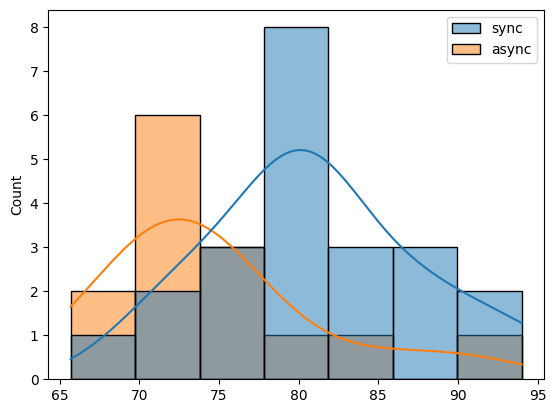

In [11]:
import seaborn as sns

sns.histplot(df_notas_covid, kde=True)

<Axes: >

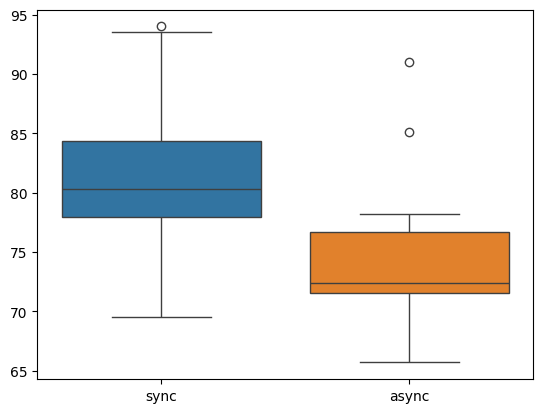

In [12]:
sns.boxplot(data=df_notas_covid)

In [13]:
from auxiliares import analises_shapiro_levene
analises_shapiro_levene(df_notas_covid)

teste de shapiro
 estatistica_sw =0.968
sync segue uma distribuição normal (valor p: 0.656)
 estatistica_sw =0.890
async segue uma distribuição normal (valor p: 0.080)

teste de levene
estatistica_levene =0.008
Variancia Iguais (valor p: 0.931)


In [14]:
from auxiliares import analise_ttest_ind

analise_ttest_ind(df_notas_covid, alternativa="greater")

teste de TT mais de uma variavel
estatistica_levene =2.841
Rejeita a hipótese nula (valor p: 0.004)


# Exercício 2

Um pediatra quer ver o efeito do consumo de fórmula no ganho médio de peso mensal (em grama) de bebês. Por esse motivo, ela coletou dados de três grupos diferentes. O primeiro grupo é composto por crianças alimentadas exclusivamente com leite materno, o segundo grupo é composto por crianças alimentadas apenas com fórmula e o último grupo é composto por crianças alimentadas com fórmula e leite materno. Esses dados estão abaixo.

De acordo com essas informações, conduza o teste de hipótese para verificar se há diferença entre o ganho médio mensal desses três grupos usando um nível de significância de 0,05. Se houver diferença significativa, realize uma análise adicional para descobrir o que causou a diferença. Antes de fazer o teste de hipótese, verifique as suposições relacionadas.

In [2]:
import pandas as pd

DADOS_LEITE_FORMULA = "./dados/leite_formula_ambos.csv"

df_leite_formula = pd.read_csv(DADOS_LEITE_FORMULA)
df_leite_formula

,apenas_leite,apenas_formula,ambos
0,794.1,898.8,976.4
1,716.9,881.2,656.4
2,993.0,940.2,861.2
3,724.7,966.2,706.8
4,760.9,957.5,718.5
5,908.2,1061.7,717.1
6,659.3,1046.2,759.8
7,690.8,980.4,894.6
8,768.7,895.6,867.6
9,717.3,919.7,805.6


In [15]:
df_leite_formula.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   apenas_leite    17 non-null     float64
 1   apenas_formula  19 non-null     float64
 2   ambos           23 non-null     float64
dtypes: float64(3)
memory usage: 684.0 bytes


In [16]:
df_leite_formula.describe()

,apenas_leite,apenas_formula,ambos
count,17.000000,19.000000,23.000000
mean,749.823529,959.215789,809.952174
std,102.007062,89.159004,79.859546
min,583.500000,796.300000,656.400000
25%,690.800000,897.200000,762.600000
50%,724.700000,952.500000,799.400000
75%,794.100000,1021.550000,864.400000
max,993.000000,1160.500000,976.400000


<Axes: ylabel='Count'>

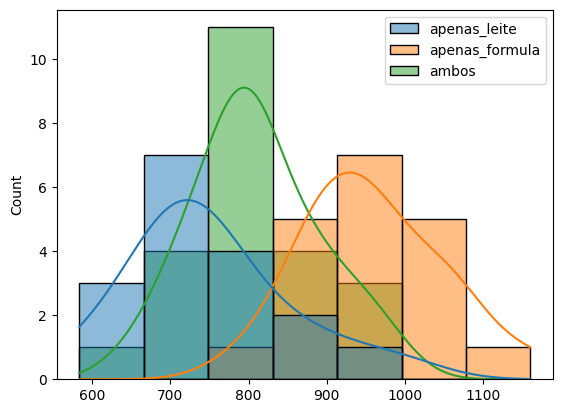

In [17]:
sns.histplot(df_leite_formula,kde=True)

<Axes: >

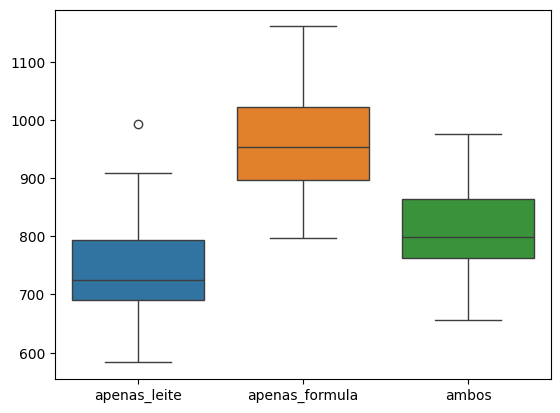

In [18]:
sns.boxplot(df_leite_formula)

In [19]:
analises_shapiro_levene(df_leite_formula)

teste de shapiro
 estatistica_sw =0.951
apenas_leite segue uma distribuição normal (valor p: 0.469)
 estatistica_sw =0.976
apenas_formula segue uma distribuição normal (valor p: 0.888)
 estatistica_sw =0.975
ambos segue uma distribuição normal (valor p: 0.797)

teste de levene
estatistica_levene =0.389
Variancia Iguais (valor p: 0.680)


In [ ]:
from auxiliares import analise_anova_one_way

analise_anova_one_way(df_leite_formula)

teste de Anova One Way
estatistica_f =26.701
Rejeita a hipótese nula (valor p: 0.000)


In [21]:
from scipy.stats import tukey_hsd

print(tukey_hsd(*[df_leite_formula[coluna].dropna() for coluna in df_leite_formula.columns]))

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)   -209.392     0.000  -281.434  -137.351
 (0 - 2)    -60.129     0.100  -129.149     8.891
 (1 - 0)    209.392     0.000   137.351   281.434
 (1 - 2)    149.264     0.000    82.365   216.162
 (2 - 0)     60.129     0.100    -8.891   129.149
 (2 - 1)   -149.264     0.000  -216.162   -82.365



# Exercício 3


Um especialista em recursos humanos que trabalha em uma empresa de tecnologia está interessado no tempo de trabalho excessivo de diferentes equipes. Para investigar se há diferença entre o tempo extra da equipe de desenvolvimento de software e da equipe de teste, ela selecionou 17 funcionários aleatoriamente em cada uma das duas equipes e registrou seu tempo médio de trabalho extra semanal em termos de hora. Os dados estão abaixo.


De acordo com essas informações, conduza o teste de hipótese para verificar se há diferença entre o tempo extra de trabalho das duas equipes usando um nível de significância de 0,05. Antes de fazer o teste de hipótese, verifique as suposições relacionadas.

In [3]:
import pandas as pd

DADOS_TEMPOS_TIMES = "./dados/tempos_times.csv"

df_tempos_times = pd.read_csv(DADOS_TEMPOS_TIMES)
df_tempos_times

,test_team,developer_team
0,6.2,2.3
1,7.1,2.1
2,1.5,1.4
3,2.0,2.0
4,3.0,8.7
5,2.0,2.2
6,1.5,3.1
7,6.1,4.2
8,2.4,3.6
9,2.3,2.5


In [22]:
df_tempos_times.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   test_team       17 non-null     float64
 1   developer_team  17 non-null     float64
dtypes: float64(2)
memory usage: 404.0 bytes


In [23]:
df_tempos_times.describe()

,test_team,developer_team
count,17.000000,17.000000
mean,4.264706,3.776471
std,3.108243,2.825228
min,1.500000,1.200000
25%,2.000000,2.200000
50%,3.000000,3.100000
75%,6.100000,3.900000
max,12.400000,12.100000


<Axes: ylabel='Count'>

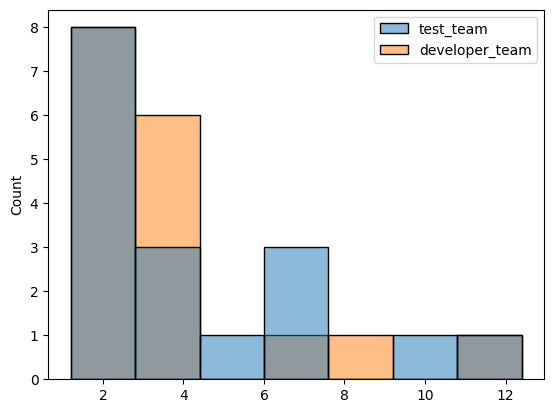

In [24]:
sns.histplot(df_tempos_times)

<Axes: >

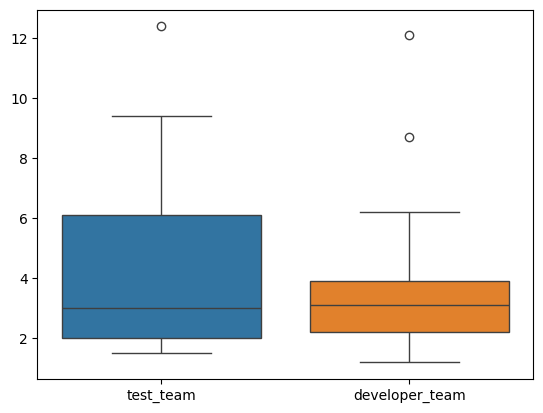

In [25]:
sns.boxplot(df_tempos_times)

In [27]:
analises_shapiro_levene(df_tempos_times,center='median')

teste de shapiro
 estatistica_sw =0.825
test_team não segue uma distribuição normal (valor p: 0.005)
 estatistica_sw =0.753
developer_team não segue uma distribuição normal (valor p: 0.000)

teste de levene
estatistica_levene =0.382
Variancia Iguais (valor p: 0.541)


In [28]:
from auxiliares import analise_mannwhitneyu

analise_mannwhitneyu(df_tempos_times)

teste de mannwhitneyu
estatistica_wilcoxon =151.500
Não rejeita a hipótese nula (valor p: 0.823)


# Exercício 4


Uma empresa de comércio eletrônico anuncia regularmente no YouTube, Instagram e Facebook para suas campanhas. No entanto, o novo gerente estava curioso para saber se havia alguma diferença entre o número de clientes atraídos por essas plataformas. Portanto, ela começou a usar o Adjust, um aplicativo que permite descobrir de onde vêm seus usuários. Os números diários relatados pelo Adjust para cada plataforma estão abaixo.

De acordo com essas informações, conduza o teste de hipótese para verificar se há diferença entre a aquisição média de clientes dessas três plataformas usando um nível de significância de 0,05. Se houver diferença significativa, realize uma análise adicional para descobrir o que causou a diferença. Antes de fazer o teste de hipótese, verifique as suposições relacionadas.

In [4]:
import pandas as pd

DADOS_ANUNCIOS = "./dados/anuncios_redes_sociais.csv"

df_anuncios = pd.read_csv(DADOS_ANUNCIOS)
df_anuncios

,youtube,instagram,facebook
0,1913,2305,2133
1,1879,2355,2522
2,1939,2203,2124
3,2146,2231,2551
4,2040,2185,2293
5,2127,2420,2367
6,2122,2386,2460
7,2156,2410,2311
8,2036,2340,2178
9,1974,2349,2113


In [29]:
df_anuncios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   youtube    15 non-null     int64
 1   instagram  15 non-null     int64
 2   facebook   15 non-null     int64
dtypes: int64(3)
memory usage: 492.0 bytes


In [30]:
df_anuncios.describe()

,youtube,instagram,facebook
count,15.000000,15.000000,15.000000
mean,2043.533333,2307.533333,2295.400000
std,100.948266,77.815594,175.281732
min,1879.000000,2185.000000,2048.000000
25%,1949.500000,2242.500000,2128.500000
50%,2040.000000,2305.000000,2293.000000
75%,2136.500000,2370.500000,2451.500000
max,2156.000000,2420.000000,2551.000000


<Axes: ylabel='Count'>

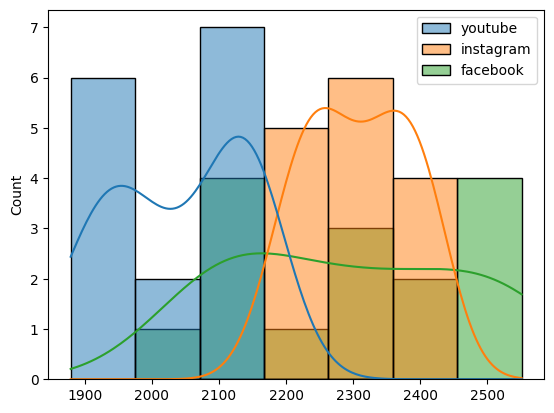

In [32]:
sns.histplot(df_anuncios,kde=True)

<Axes: >

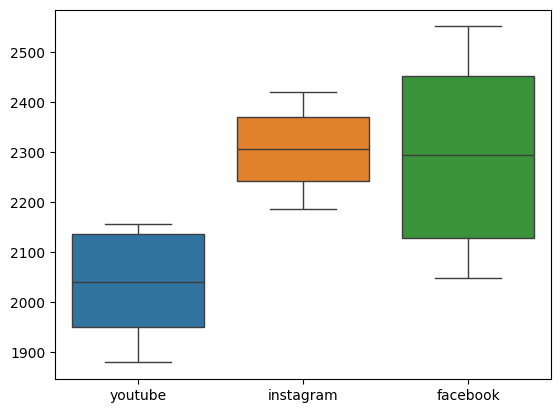

In [33]:
sns.boxplot(df_anuncios)

In [34]:
analises_shapiro_levene(df_anuncios,center="median")

teste de shapiro
 estatistica_sw =0.865
youtube não segue uma distribuição normal (valor p: 0.029)
 estatistica_sw =0.943
instagram segue uma distribuição normal (valor p: 0.416)
 estatistica_sw =0.917
facebook segue uma distribuição normal (valor p: 0.172)

teste de levene
estatistica_levene =7.887
Pelo menos uma variancia é diferente (valor p: 0.001)


In [35]:
from scipy.stats import kruskal

kruskal(df_anuncios['facebook'],df_anuncios['instagram'],df_anuncios['youtube'])

KruskalResult(statistic=np.float64(22.19353931967411), pvalue=np.float64(1.516122070070448e-05))

rejeita a hipótese nula p = 0

# Exercício 5

O Centro de Saúde de uma universidade diagnosticou dezoito estudantes com colesterol alto no semestre anterior. O pessoal de saúde informou a esses pacientes sobre os perigos do colesterol alto e prescreveu um programa de dieta. Um mês depois, os pacientes vieram para controle, e seu nível de colesterol foi reexaminado. Teste se há diferença nos níveis de colesterol dos pacientes.

De acordo com essas informações, conduza o teste de hipótese para verificar se há uma diminuição nos níveis de colesterol dos pacientes após a dieta, usando um nível de significância de 0,05. Antes de fazer o teste de hipótese, verifique as suposições relacionadas. Comente sobre os resultados.

In [5]:
import pandas as pd

DADOS_COLESTEROL = "./dados/dieta_colesterol.csv"

df_colesterol = pd.read_csv(DADOS_COLESTEROL)
df_colesterol

,antes_dieta,depois_dieta
0,224,198
1,235,195
2,223,213
3,253,190
4,253,246
5,224,206
6,244,225
7,225,199
8,259,214
9,220,210


In [36]:
df_colesterol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   antes_dieta   18 non-null     int64
 1   depois_dieta  18 non-null     int64
dtypes: int64(2)
memory usage: 420.0 bytes


In [37]:
df_colesterol.describe()

,antes_dieta,depois_dieta
count,18.000000,18.000000
mean,239.111111,205.944444
std,15.238839,14.972415
min,220.000000,188.000000
25%,225.500000,195.750000
50%,238.000000,202.500000
75%,250.750000,213.750000
max,276.000000,246.000000


<Axes: ylabel='Count'>

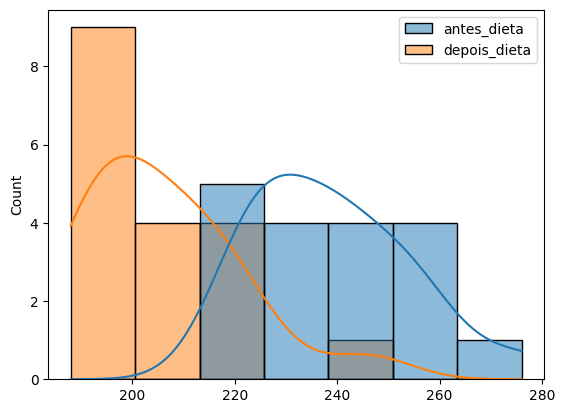

In [38]:
sns.histplot(df_colesterol,kde=True)

<Axes: >

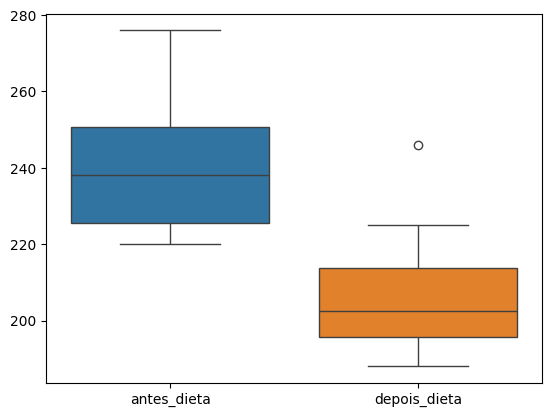

In [39]:
sns.boxplot(df_colesterol)

In [40]:
analises_shapiro_levene(df_colesterol)

teste de shapiro
 estatistica_sw =0.926
antes_dieta segue uma distribuição normal (valor p: 0.163)
 estatistica_sw =0.914
depois_dieta segue uma distribuição normal (valor p: 0.100)

teste de levene
estatistica_levene =0.019
Variancia Iguais (valor p: 0.892)


In [43]:
from auxiliares import analise_ttest_rel

analise_ttest_rel(df_colesterol,alternativa="greater")

teste de Rel l
estatistica_levene =6.315
Rejeita a hipótese nula (valor p: 0.000)


# Exercício 6


Uma gestora de um fundo de investimentos queria investir em uma startup que fornece compressão de dados sem perda de qualidade, mas existem dois concorrentes: PiedPiper e EndFrame. Inicialmente, ela acreditava que o desempenho do EndFrame poderia ser melhor, mas ainda queria testá-lo antes do investimento. Em seguida, ela deu os mesmos arquivos para cada empresa comprimir e registrou suas pontuações de desempenho. Os dados estão abaixo.

De acordo com essas informações, conduza o teste de hipótese relacionado usando um nível de significância de 0,05. Antes de fazer o teste de hipótese, verifique as suposições relacionadas. Comente sobre os resultados.

In [6]:
import pandas as pd

DADOS_COMPRESSAO = "./dados/tempos_compressao.csv"

df_tempos_compressao = pd.read_csv(DADOS_COMPRESSAO)
df_tempos_compressao

,piedpiper,endframe
0,4.57,4.27
1,4.55,3.93
2,5.47,4.01
3,4.67,4.07
4,5.41,3.87
5,5.55,4.00
6,5.53,4.00
7,5.63,3.72
8,3.86,4.16
9,3.97,4.10


In [44]:
df_tempos_compressao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   piedpiper  17 non-null     float64
 1   endframe   17 non-null     float64
dtypes: float64(2)
memory usage: 404.0 bytes


In [45]:
df_tempos_compressao.describe()

,piedpiper,endframe
count,17.000000,17.000000
mean,4.881176,3.991765
std,0.632583,0.135565
min,3.860000,3.720000
25%,4.390000,3.930000
50%,5.170000,4.000000
75%,5.440000,4.080000
max,5.630000,4.270000


<Axes: ylabel='Count'>

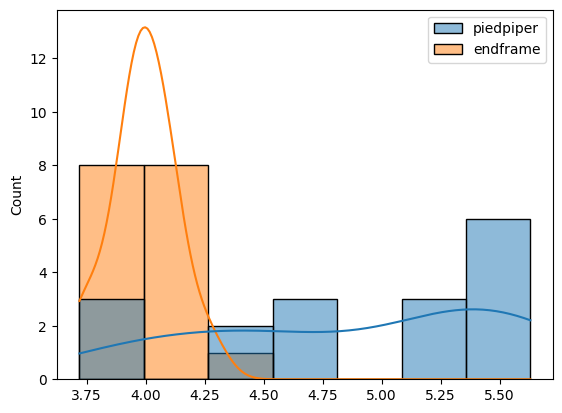

In [46]:
sns.histplot(df_tempos_compressao,kde=True)

<Axes: >

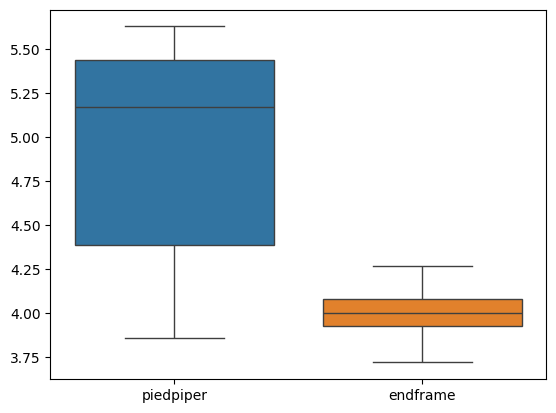

In [47]:
sns.boxplot(df_tempos_compressao)

In [49]:
analises_shapiro_levene(df_tempos_compressao,center="median")

teste de shapiro
 estatistica_sw =0.879
piedpiper não segue uma distribuição normal (valor p: 0.030)
 estatistica_sw =0.980
endframe segue uma distribuição normal (valor p: 0.959)

teste de levene
estatistica_levene =19.907
Pelo menos uma variancia é diferente (valor p: 0.000)


In [50]:
from auxiliares import analise_wilcoxon

analise_wilcoxon(df_tempos_compressao)

teste de Wilcoxon
estatistica_wilcoxon =6.000
Rejeita a hipótese nula (valor p: 0.000)


# Exercício 7

Uma pesquisadora estava curiosa para saber se há diferença entre a metodologia que ela desenvolveu para detectar a concentração de uma droga em amostras de sangue, C, e os métodos de linha de base A e B em termos de desempenho. Portanto, ela decidiu projetar diferentes experimentos e registrou a precisão alcançada por cada método. A tabela abaixo mostra a precisão alcançada nos conjuntos de teste por cada método. Observe que os mesmos conjuntos de treinamento e teste foram usados para cada método.

De acordo com essas informações, conduza o teste de hipótese para verificar se há diferença entre o desempenho dos métodos usando um nível de significância de 0,05. Se houver diferença significativa, realize uma análise adicional para descobrir o que causou a diferença. Antes de fazer o teste de hipótese, verifique as suposições relacionadas. Comente sobre os resultados.

In [7]:
import pandas as pd

DADOS_METODOS = "./dados/metodos_deteccao_sangue.csv"

df_metodos = pd.read_csv(DADOS_METODOS)
df_metodos

,metodo_A,metodo_B,metodo_C
0,89.8,90.0,91.5
1,89.9,90.1,90.7
2,88.6,88.8,90.3
3,88.7,88.9,90.4
4,89.6,89.9,90.2
5,89.7,90.0,90.3
6,89.2,89.0,90.2
7,89.3,89.2,90.3


In [51]:
df_metodos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   metodo_A  8 non-null      float64
 1   metodo_B  8 non-null      float64
 2   metodo_C  8 non-null      float64
dtypes: float64(3)
memory usage: 324.0 bytes


In [52]:
df_metodos.describe()

,metodo_A,metodo_B,metodo_C
count,8.000000,8.000000,8.000000
mean,89.350000,89.487500,90.487500
std,0.492805,0.561726,0.438952
min,88.600000,88.800000,90.200000
25%,89.075000,88.975000,90.275000
50%,89.450000,89.550000,90.300000
75%,89.725000,90.000000,90.475000
max,89.900000,90.100000,91.500000


<Axes: ylabel='Count'>

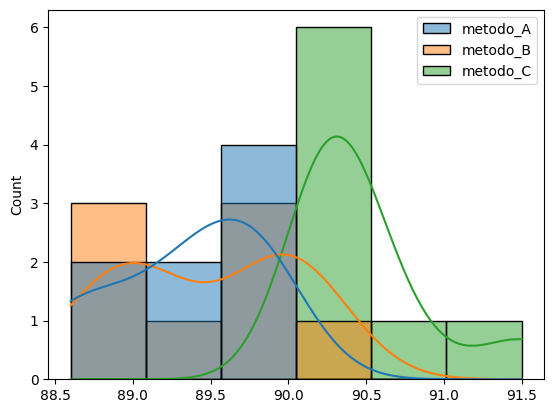

In [53]:
sns.histplot(df_metodos,kde=True)

<Axes: >

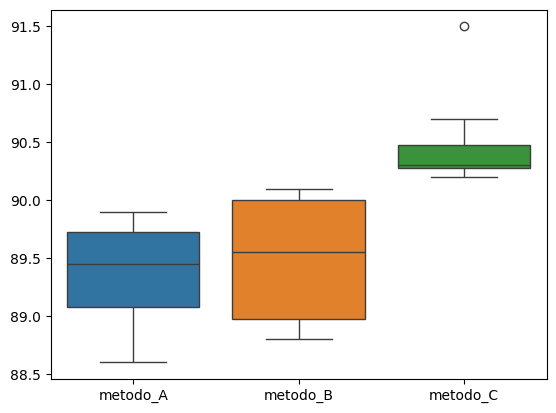

In [54]:
sns.boxplot(df_metodos)

In [56]:
analises_shapiro_levene(df_metodos,center="median")

teste de shapiro
 estatistica_sw =0.903
metodo_A segue uma distribuição normal (valor p: 0.308)
 estatistica_sw =0.824
metodo_B segue uma distribuição normal (valor p: 0.052)
 estatistica_sw =0.686
metodo_C não segue uma distribuição normal (valor p: 0.002)

teste de levene
estatistica_levene =1.767
Variancia Iguais (valor p: 0.195)


In [57]:
from scipy.stats import friedmanchisquare

friedmanchisquare(df_metodos["metodo_A"],df_metodos["metodo_B"],df_metodos["metodo_C"])

FriedmanchisquareResult(statistic=np.float64(13.0), pvalue=np.float64(0.0015034391929775717))

Nesse nivel de significancia, há evidências suficientes para concluir que o desempenho dos métodos é diferente

no boxplot, o metodo C é melhor que os outros dois

# Exercício 8

Um analista de uma empresa de investimentos financeiros está curioso sobre a relação entre gênero e apetite por risco. Uma amostra aleatória foi retirada do banco de dados com 660 clientes. Os clientes da amostra foram classificados de acordo com seu gênero e seu apetite por risco. O resultado é dado na tabela a seguir.

Gênero/Risco |	Muito Baixo 	| Baixo |	Médio | 	Alto | 	Muito Alto | 	Total
--- | --- | --- | --- | --- | --- | ---
Feminino |  53 	| 23 | 30 |	36 |	88 |	230
Masculino 	| 71 	| 48 |	51 	| 57 	| 203 	| 430
Total 	| 124 	| 71 | 	81 |	93 |	291 |	660

Teste a hipótese de que o apetite por risco dos clientes nesta empresa é independente de seu gênero. Use **α = 0,01**.


In [60]:
import pandas as pd

DADOS_GENEROS_RISCO = "./dados/risco_genero.csv"

df_risco = pd.read_csv(DADOS_GENEROS_RISCO, index_col=0)
df_risco

,muito_baixo,baixo,medio,alto,muito_alto
feminino,53,23,30,36,88
masculino,71,48,51,57,203


In [59]:
from scipy.stats import chi2_contingency

chi2_contingency(df_risco)

Chi2ContingencyResult(statistic=np.float64(7.094218206100441), pvalue=np.float64(0.13099220858734012), dof=4, expected_freq=array([[ 43.21212121,  24.74242424,  28.22727273,  32.40909091,
        101.40909091],
       [ 80.78787879,  46.25757576,  52.77272727,  60.59090909,
        189.59090909]]))